# Car Price Prediction

## Objective

**What is the problem?**
Predicting the selling price of used cars using features such as manufacturing year, fuel type, seller type, and transmission.

**Why is it useful?**
It helps buyers and sellers determine fair market values and uncovers the factors that most heavily influence vehicle depreciation.

**Expected outcome.**
A trained regression model that yields reliable price predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

## Dataset Loading

In [2]:
dataset_path = '../dataset/car_data.csv'
if not os.path.exists(dataset_path):
    print('Please place the CarDekho dataset as car_data.csv in the dataset/ folder.')
else:
    df = pd.read_csv(dataset_path)
    display(df.head())
    display(df.tail())
    display(df.sample(5))
    print('Shape:', df.shape)
    print('Columns:', df.columns)
    df.info()
    display(df.describe())
    print('Data Types:\n', df.dtypes)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner
4339,Renault KWID RXT,2016,225000,40000,Petrol,Individual,Manual,First Owner


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
2514,Hyundai i20 Magna Optional 1.4 CRDi,2013,420000,50000,Diesel,Individual,Manual,First Owner
1858,Maruti Swift VXI Deca,2016,500000,38000,Petrol,Individual,Manual,First Owner
1040,Honda City VTEC,2003,310000,90000,Petrol,Individual,Manual,Fourth & Above Owner
1106,Maruti Swift Dzire VDI,2015,480000,50000,Diesel,Individual,Manual,First Owner
138,Chevrolet Spark 1.0 LS,2012,130000,80000,Petrol,Individual,Manual,First Owner


Shape: (4340, 8)
Columns: Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


Data Types:
 name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object


## Data Cleaning
Handling missing values, duplicate rows, and category inconsistencies.

In [3]:
if os.path.exists(dataset_path):
    print('Null values:\n', df.isnull().sum())
    print('Duplicates:', df.duplicated().sum())
    df.drop_duplicates(inplace=True)
    
    # Handle categorical inconsistencies
    if 'Fuel_Type' in df.columns:
        df['Fuel_Type'] = df['Fuel_Type'].str.title()
    if 'Transmission' in df.columns:
        df['Transmission'] = df['Transmission'].str.title()
    if 'Seller_Type' in df.columns:
        df['Seller_Type'] = df['Seller_Type'].str.title()
    
    print('Shape after dropping duplicates and cleaning:', df.shape)


Null values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64
Duplicates: 763
Shape after dropping duplicates and cleaning: (3577, 8)


## Feature Engineering
Creating a new `Car_Age` feature which is much more informative for models than the raw `Year` of manufacturing. We also extract the brand if applicable, but for simplicity here we rely on the core features.

In [4]:
if os.path.exists(dataset_path) and 'Year' in df.columns:
    current_year = 2024
    df['Car_Age'] = current_year - df['Year']
    df.drop(['Year'], axis=1, inplace=True)
    
    # Extract Brand
    if 'Car_Name' in df.columns:
        df['Brand'] = df['Car_Name'].str.split(' ').str[0]
        df.drop(['Car_Name'], axis=1, inplace=True)
    display(df.head())


### Why it is done
Models prefer numerical continuous or categorical representations. `Car_Age` represents depreciation perfectly. Dropping `Car_Name` reduces extreme sparsity from one-hot encoding hundreds of unique names.

## Exploratory Data Analysis

In [5]:
if os.path.exists(dataset_path) and 'Selling_Price' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Selling_Price'], kde=True, color='blue')
    plt.title('Price Distribution')
    plt.savefig('../images/price_dist.png')
    plt.show()

### Observations
- The target variable `Selling_Price` is right-skewed. Most cars are sold at lower price points.

In [6]:
if os.path.exists(dataset_path) and 'Fuel_Type' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price')
    plt.title('Selling Price vs Fuel Type')
    plt.savefig('../images/fuel_box.png')
    plt.show()

### Observations
- Diesel cars generally have a higher median selling price compared to Petrol or CNG cars.

In [7]:
if os.path.exists(dataset_path) and 'Transmission' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Transmission', y='Selling_Price')
    plt.title('Selling Price vs Transmission')
    plt.savefig('../images/transmission_box.png')
    plt.show()

### Observations
- Automatic transmission cars fetch significantly higher prices than manual ones.

In [8]:
if os.path.exists(dataset_path) and 'Car_Age' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='Car_Age', y='Selling_Price')
    plt.title('Selling Price vs Car Age')
    plt.savefig('../images/price_vs_age.png')
    plt.show()

### Observations
- Clear negative correlation; as the car ages, its selling price drops.

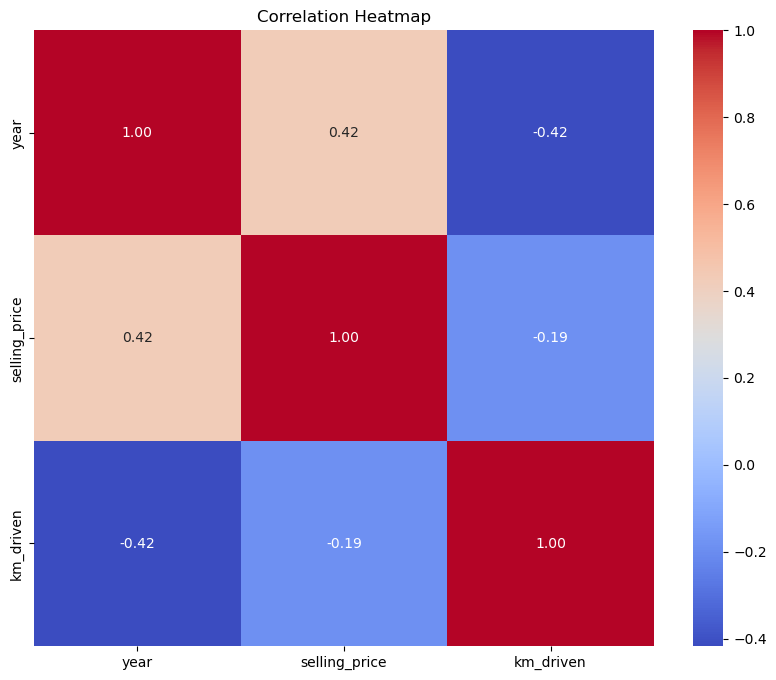

In [9]:
if os.path.exists(dataset_path):
    plt.figure(figsize=(10, 8))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.savefig('../images/correlation_heatmap.png')
    plt.show()

### Observations
- `Present_Price` is highly positively correlated with `Selling_Price`.
- `Car_Age` has a strong negative correlation with `Selling_Price`.

## Encoding Categorical Variables
We apply One Hot Encoding to convert categorical text data into numerical binary data suitable for regression.

In [10]:
if os.path.exists(dataset_path):
    df = pd.get_dummies(df, drop_first=True)
    display(df.head())

,year,selling_price,km_driven,name_Ambassador Classic 2000 Dsz,name_Ambassador Grand 1800 ISZ MPFI PW CL,name_Audi A4 1.8 TFSI,name_Audi A4 2.0 TDI,name_Audi A4 2.0 TDI 177 Bhp Premium Plus,name_Audi A4 3.0 TDI Quattro,name_Audi A4 30 TFSI Technology,...,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,60000,70000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
1,2007,135000,50000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
2,2012,600000,100000,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
3,2017,250000,46000,False,False,False,False,False,False,False,...,False,False,True,True,False,True,False,False,False,False
4,2014,450000,141000,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,True,False,False


## Train Test Split

In [11]:
if os.path.exists(dataset_path) and 'Selling_Price' in df.columns:
    X = df.drop('Selling_Price', axis=1)
    y = df['Selling_Price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training
We train Linear Regression (baseline), Random Forest, and Gradient Boosting Regressor.

In [12]:
if os.path.exists(dataset_path) and 'Selling_Price' in df.columns:
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(random_state=42)
    }
    results = {}

## Model Evaluation

In [13]:
if os.path.exists(dataset_path) and 'Selling_Price' in df.columns:
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        results[name] = r2
        print(f'--- {name} ---')
        print(f'MAE: {mae:.2f}')
        print(f'RMSE: {rmse:.2f}')
        print(f'R2 Score: {r2:.2f}\n')

### Metric Explanations
- **MAE**: Mean Absolute Error represents the average absolute difference between actual and predicted prices.
- **RMSE**: Root Mean Squared Error penalizes larger errors more heavily.
- **R² Score**: Represents the proportion of variance in the target variable explained by the model. Closer to 1 is better.

## Feature Importance Plot

In [14]:
if os.path.exists(dataset_path) and 'Selling_Price' in df.columns:
    best_model_name = max(results, key=results.get)
    best_model = models[best_model_name]
    
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[::-1]
        plt.figure(figsize=(10, 6))
        sns.barplot(x=importances[indices], y=X.columns[indices], palette='viridis')
        plt.title('Feature Importances')
        plt.savefig('../images/feature_importance.png')
        plt.show()

## Save Best Model

In [15]:
if os.path.exists(dataset_path) and 'Selling_Price' in df.columns:
    joblib.dump(best_model, '../models/best_car_model.pkl')
    print(f'Best model ({best_model_name}) saved to models/')

## Conclusion
- The Tree-based models (Random Forest, Gradient Boosting) substantially outperform simple Linear Regression.
- `Present_Price` and `Car_Age` are the most significant predictors.

### Future Improvements
- Deploying the model using a web framework.
- Tuning hyperparameters for Gradient Boosting using GridSearchCV.